# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Google | Human | Meta | Mistral | OpenAI

## 0. Setup — Imports e Configuração

In [2]:
import sys
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch version: 2.10.0+cu128
Device: cpu


In [ ]:
# Hiperparâmetros 

CLASSES       = ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 2000     # tamanho do vocabulário TF-IDF
MAX_LEN       = 150      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 10000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 128      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 10       # early stopping

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

Total de exemplos: 4931

Distribuição por classe:


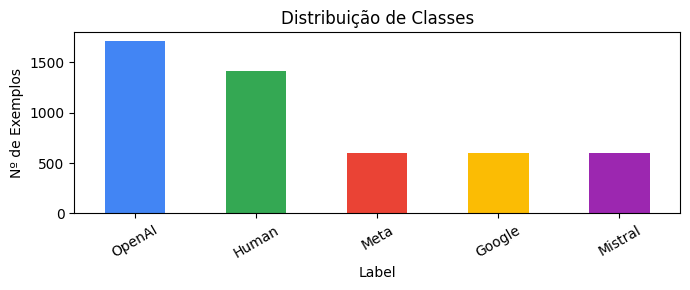

In [4]:
# Carregar dataset
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos: {len(texts)}")
print("\nDistribuição por classe:")
df['Label'].value_counts().plot(kind='bar', color=['#4285F4','#34A853','#EA4335','#FBBC04','#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [5]:
# Split treino / validação / teste
X_tr, X_te, y_tr, y_te = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE, stratify=y_tr)

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste:     {len(X_te)} exemplos")

Treino:    3451 exemplos
Validação: 493 exemplos
Teste:     987 exemplos


In [ ]:
# Datasets TF-IDF (para Baseline e DNN) 
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU) 
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")

Vocabulário (Embeddings): 10002 palavras


## Funções de Visualização

In [8]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [9]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...
Epoch 1/100 | train_loss: 1.5189 | train_acc: 0.5694 | val_loss: 1.5256 | val_acc: 0.5416
Epoch 2/100 | train_loss: 1.4447 | train_acc: 0.5891 | val_loss: 1.4590 | val_acc: 0.5517
Epoch 3/100 | train_loss: 1.3822 | train_acc: 0.5975 | val_loss: 1.4038 | val_acc: 0.5659
Epoch 4/100 | train_loss: 1.3277 | train_acc: 0.6030 | val_loss: 1.3561 | val_acc: 0.5761
Epoch 5/100 | train_loss: 1.2790 | train_acc: 0.6085 | val_loss: 1.3143 | val_acc: 0.5822
Epoch 6/100 | train_loss: 1.2344 | train_acc: 0.6111 | val_loss: 1.2761 | val_acc: 0.5882
Epoch 7/100 | train_loss: 1.1932 | train_acc: 0.6210 | val_loss: 1.2412 | val_acc: 0.6004
Epoch 8/100 | train_loss: 1.1547 | train_acc: 0.6320 | val_loss: 1.2082 | val_acc: 0.6085
Epoch 9/100 | train_loss: 1.1184 | train_acc: 0.6491 | val_loss: 1.1776 | val_acc: 0.6105
Epoch 10/100 | train_loss: 1.0839 | train_acc: 0.6665 | val_loss: 1.1486 | val_acc: 0.6288
Epoch 11/100 | train_loss: 1.0516 | train_ac

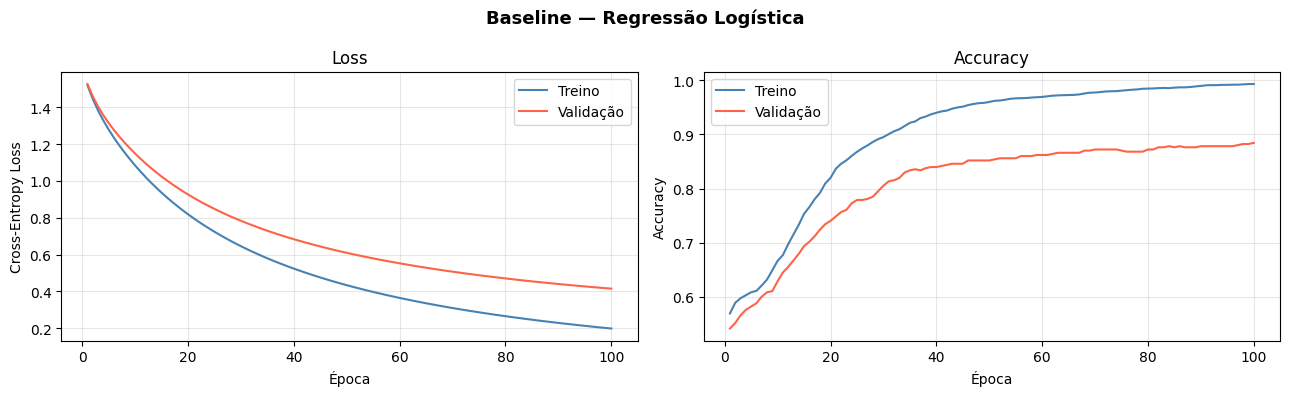


>>> Accuracy no Teste (Baseline): 86.52%


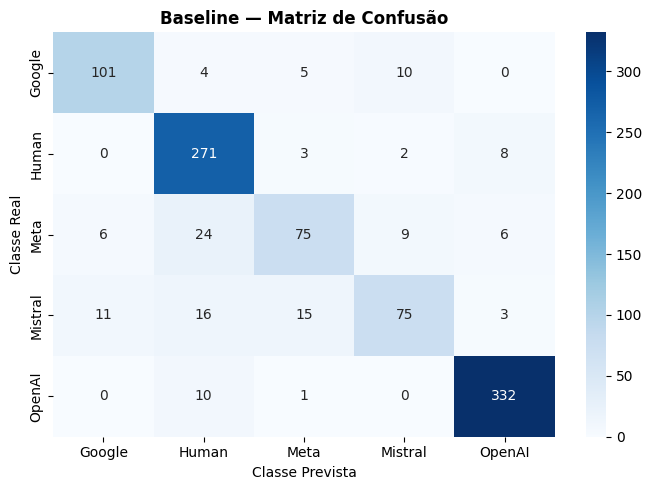

              precision    recall  f1-score   support

      Google       0.86      0.84      0.85       120
       Human       0.83      0.95      0.89       284
        Meta       0.76      0.62      0.68       120
     Mistral       0.78      0.62      0.69       120
      OpenAI       0.95      0.97      0.96       343

    accuracy                           0.87       987
   macro avg       0.84      0.80      0.82       987
weighted avg       0.86      0.87      0.86       987



In [ ]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [ ]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

In [ ]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [ ]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(lstm, train_loader_seq, val_loader_seq, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

In [ ]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [ ]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(gru, train_loader_seq, val_loader_seq, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

In [ ]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos

In [ ]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [ ]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

---
## 8. Carregar e Usar um Modelo Guardado

In [ ]:
# Exemplo: carregar o DNN e classifcar um texto novo
model_loaded = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_loaded.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', weights_only=True))
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)